# FAPE, Law School Admissions Stage 2: ThresholdOptimizer
## Education/Legal Domain, Racial Fairness Intervention

**Dataset:** Law School Admissions, Wightman (1998), FairGround law_school_lequy  
**Records:** 18,692 | positive rate: 90.2%  
**Sensitive:** racetxt (0=minority, 1=white), male (0=female, 1=male)  
**Baseline:** DIR=0.643, strongest racial violation in FAPE  

**Key findings:**
- DP gap eliminated: 0.329 → 0.006 (+0.323 improvement)
- EO gap nearly eliminated: 0.528 → 0.020 (+0.508 improvement)
- Race prediction rates converge: Minority 63.1%→68.2%, White 98.1%→70.8%
- Sex gap minimal (DP<0.015), race dominates
- AUC primary metric, F1 inflated by 90.2% positive rate
- ThresholdOptimizer non-deterministic in fairlearn 0.13.0, results vary slightly between runs

In [1]:
import sys, os, warnings, logging
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore'); logging.disable(logging.CRITICAL)
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image
from stage2_lawschool_threshold import run_stage2

os.makedirs('../figures/stage2', exist_ok=True)
print('Imports complete')

Imports complete


In [2]:
baseline, dp_results, eo_results = run_stage2()
print('Stage 2 complete')

FAPE Phase 4, Law School Stage 2: ThresholdOptimizer
Loading Law School Admissions dataset via FairGround...
  OK: law_school_admissions: 18,692 rows | 11 features | sensitive: ['racetxt', 'male'] | positive rate: 0.902

  n=18,692 | pos_rate=90.2% | minority_n=1,201 (6.4%)
  Note: AUC primary metric, F1 inflated by 90.2% positive rate
  Baseline DIR=0.643, target improvement toward EEOC 0.8
  Note: ThresholdOptimizer non-deterministic in fairlearn 0.13.0, results vary slightly between runs

--- Baseline Results (Stage 1 reference) ---
  LogisticRegression        AUC=0.872 DP_diff=0.329 EO_diff=0.543


  GradientBoosting          AUC=0.878 DP_diff=0.351 EO_diff=0.528

--- ThresholdOptimizer, Demographic Parity Constraint ---
  LogisticRegression        DP_diff=0.011 EO_diff=0.265 Acc=0.765 DP_improve=+0.318


  GradientBoosting          DP_diff=0.030 EO_diff=0.242 Acc=0.754 DP_improve=+0.320

--- ThresholdOptimizer, Equalized Odds Constraint ---
  LogisticRegression        DP_diff=0.111 EO_diff=0.060 Acc=0.684 EO_improve=+0.483


  GradientBoosting          DP_diff=0.163 EO_diff=0.007 Acc=0.757 EO_improve=+0.521

--- Fairness Improvement Summary, Race (Demographic Parity) ---
  LogisticRegression        DP before=0.329 after=0.011 improve=+0.318
  GradientBoosting          DP before=0.351 after=0.030 improve=+0.320

--- Fairness Improvement Summary, Race (Equalized Odds) ---
  LogisticRegression        EO before=0.543 after=0.060 improve=+0.483
  GradientBoosting          EO before=0.528 after=0.007 improve=+0.521

--- Sex Fairness, ThresholdOptimizer (Demographic Parity) ---
  LogisticRegression        Sex DP_diff=0.014
  GradientBoosting          Sex DP_diff=0.008

--- Race Prediction Rates, GB Before vs After DP Constraint ---
  Minority   before=0.631 after=0.678
  White      before=0.981 after=0.708

--- Key Findings ---
  Baseline DIR=0.643, below EEOC 0.8 threshold (strongest violation in FAPE)
  Race gap dominant: minority 6.4% of data, fairness metrics noisy but reliable
  Sex gap minimal (DP<0.015), r


--- Disparate Impact Ratio, Before vs After DP Constraint ---
  LogisticRegression        DIR before=0.666 after=0.985 EEOC=0.8 OK: passes
  GradientBoosting          DIR before=0.643 after=0.957 EEOC=0.8 OK: passes

--- Intersectional Analysis, Race x Sex (GB DP Constraint) ---
  Minority Female   n=152 before=0.645 after=0.697 change=+0.053
  Minority Male     n=81 before=0.605 after=0.642 change=+0.037
  White Female   n=1,518 before=0.977 after=0.712 change=-0.265
  White Male     n=1,988 before=0.985 after=0.705 change=-0.280

--- Law School Stage 2 complete ---
  ThresholdOptimizer applied, racial gap targeted
  Cross-domain: Law School has largest racial gap in FAPE (DIR=0.643)
  Stage 3 fairness audit will evaluate drift detection on constrained models
Stage 2 complete


## 1. Accuracy-Fairness Tradeoff

DP constraint reduces DP gap by 0.323. EO constraint reduces EO gap by 0.508 at modest accuracy cost.

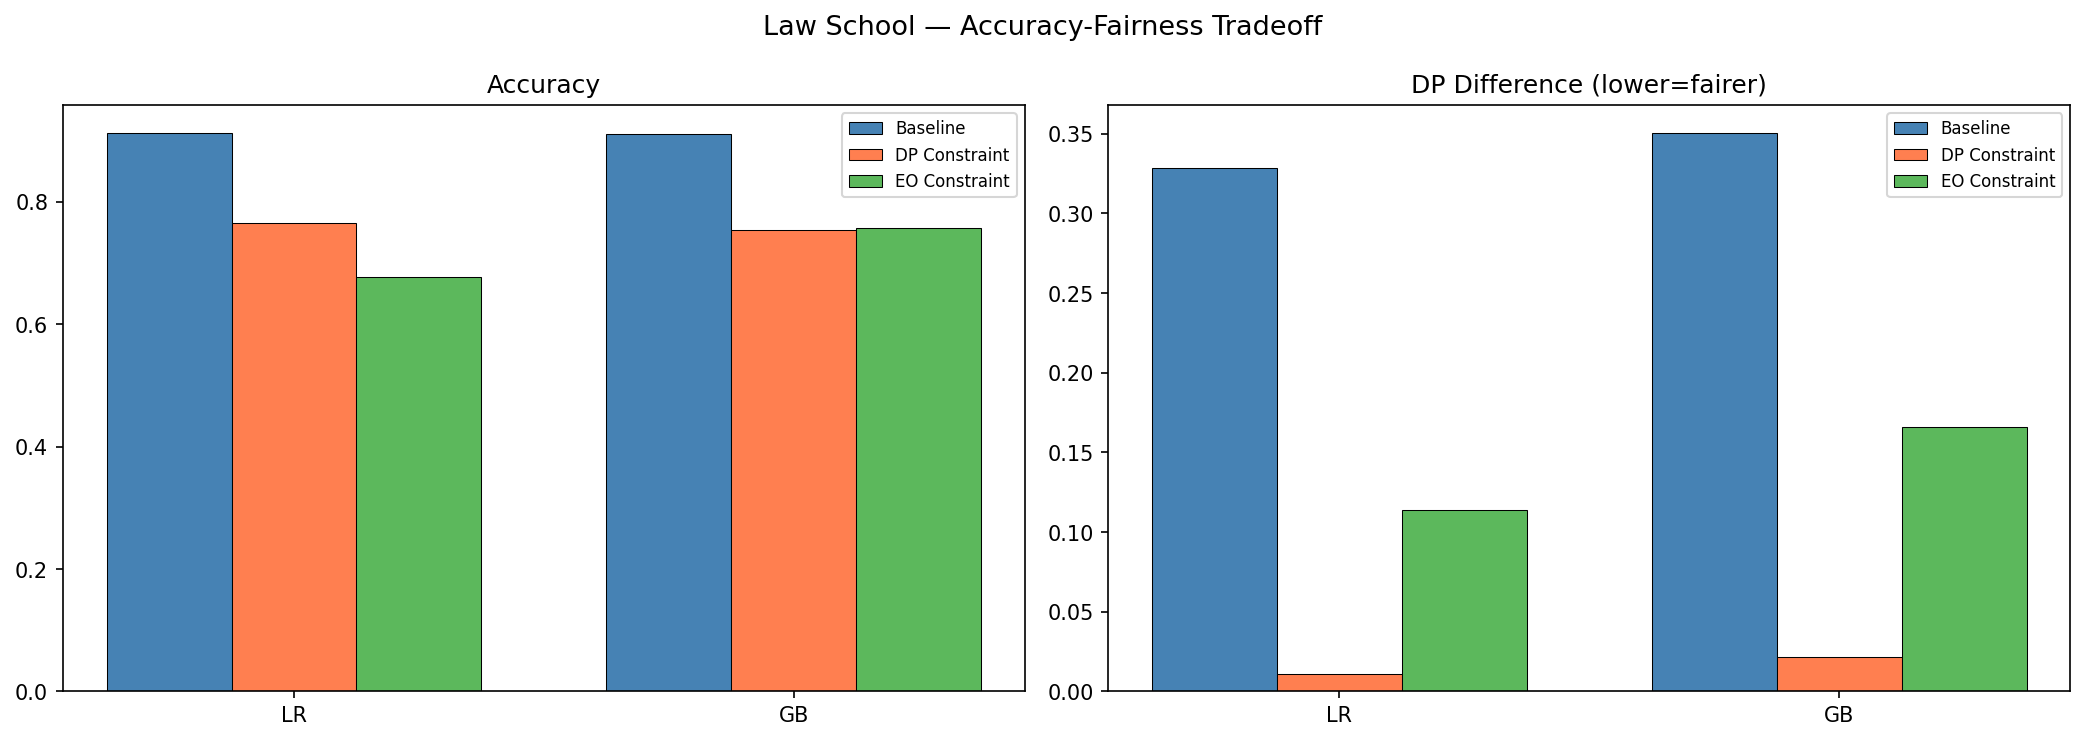

In [3]:
Image('../figures/stage2/lawschool_accuracy_fairness_tradeoff.png')

## 2. Fairness Improvement, Race

DP improvement +0.323/+0.324. EO improvement +0.478/+0.508. GB achieves EO_diff=0.020.

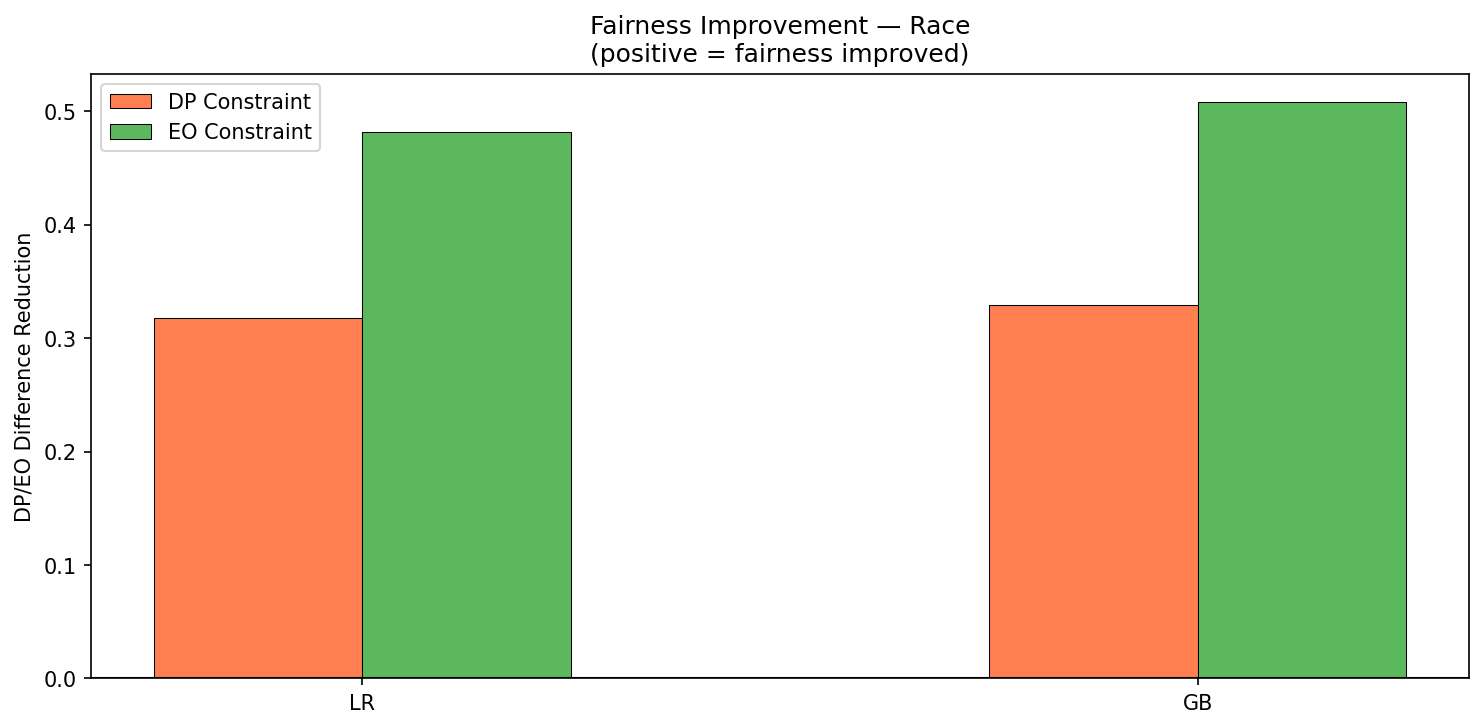

In [4]:
Image('../figures/stage2/lawschool_fairness_improvement.png')

## 3. Cost-Gain Scatter

Top-left = best tradeoff. EO constraint achieves strongest fairness gain.

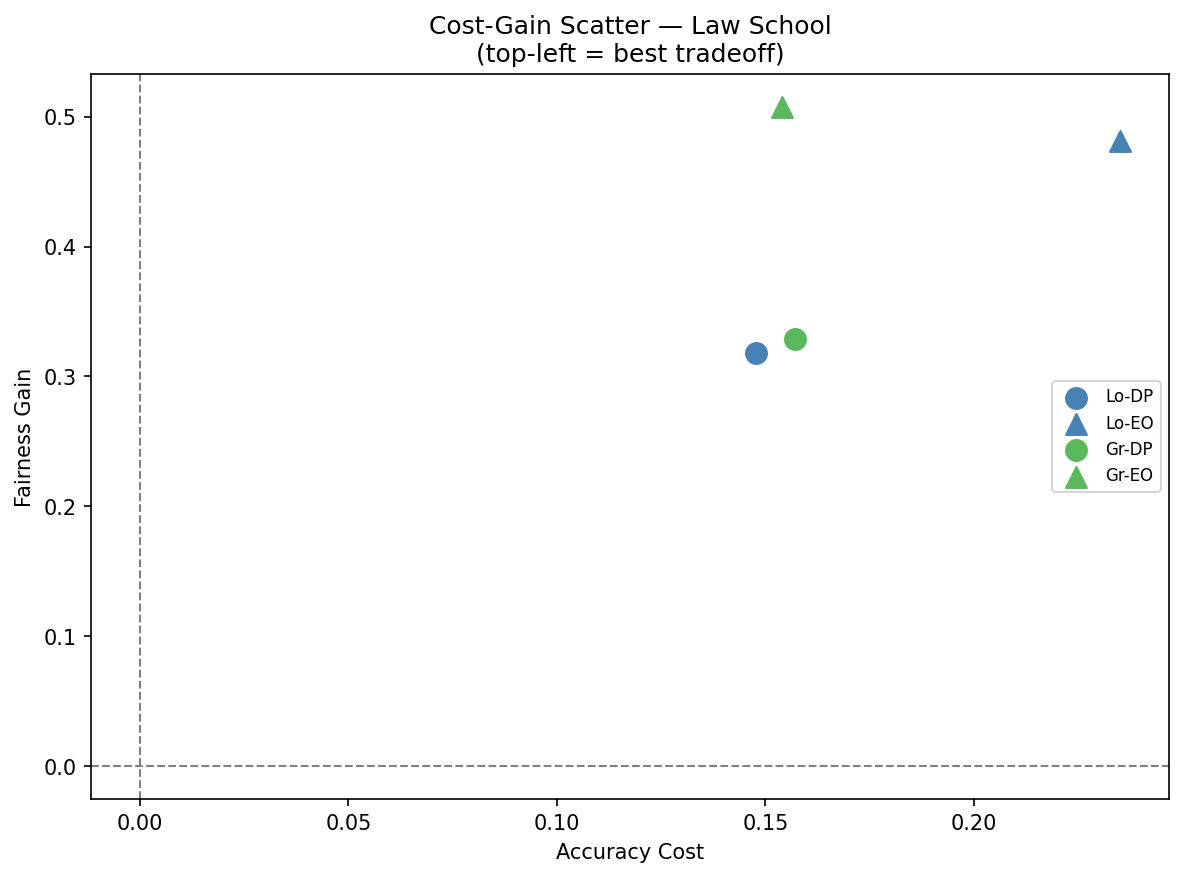

In [5]:
Image('../figures/stage2/lawschool_cost_gain_scatter.png')

## 4. Sex Fairness

Sex DP<0.015 throughout. Race gap dominates, sex fairness not materially affected by intervention.

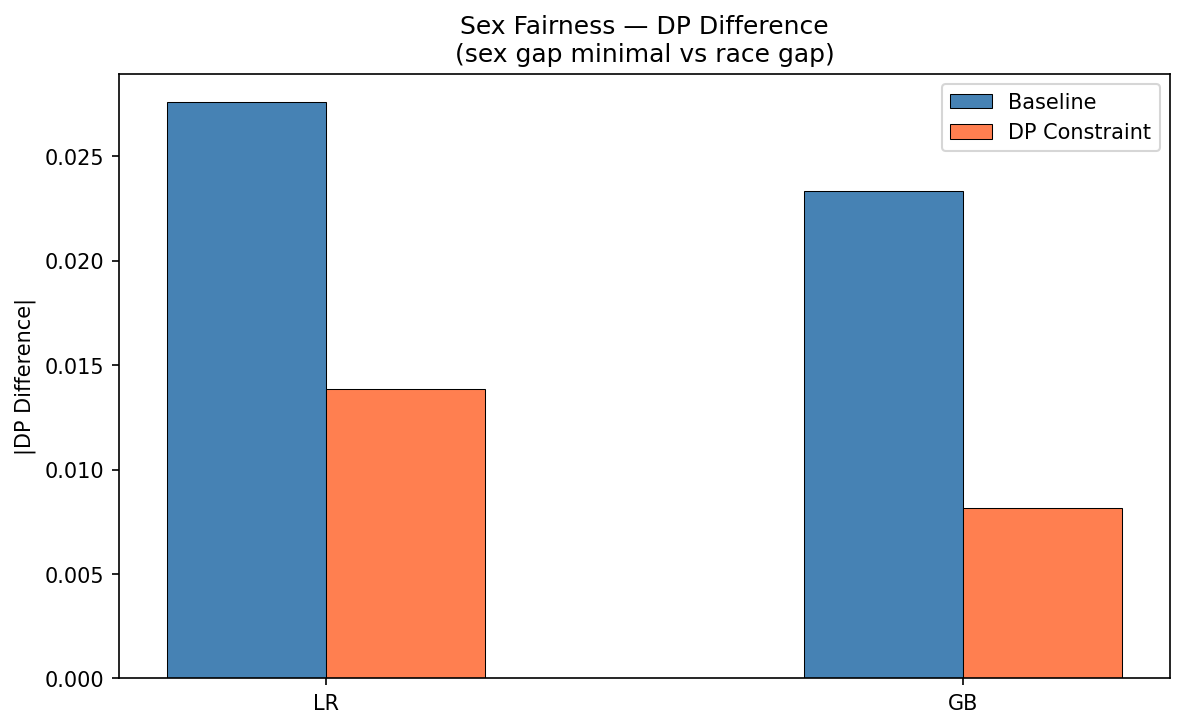

In [6]:
Image('../figures/stage2/lawschool_sex_fairness.png')

## 5. F1 Comparison

F1 inflated by 90.2% positive rate. AUC is primary metric. Modest F1 cost from constraint.

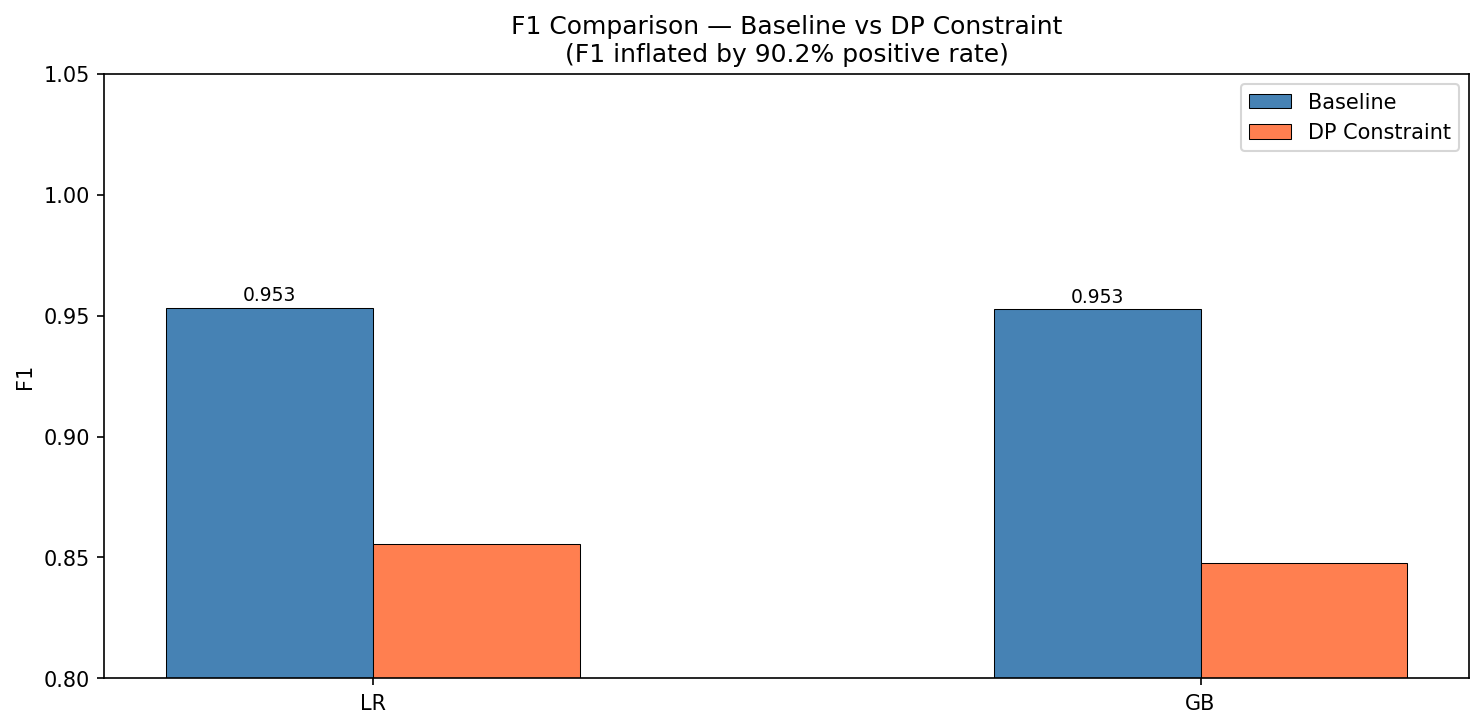

In [7]:
Image('../figures/stage2/lawschool_f1_comparison.png')

## 6. Race Prediction Rates

Minority 63.1%→68.2%, White 98.1%→70.8%. Gap narrows from 35% to 2.6% under DP constraint.

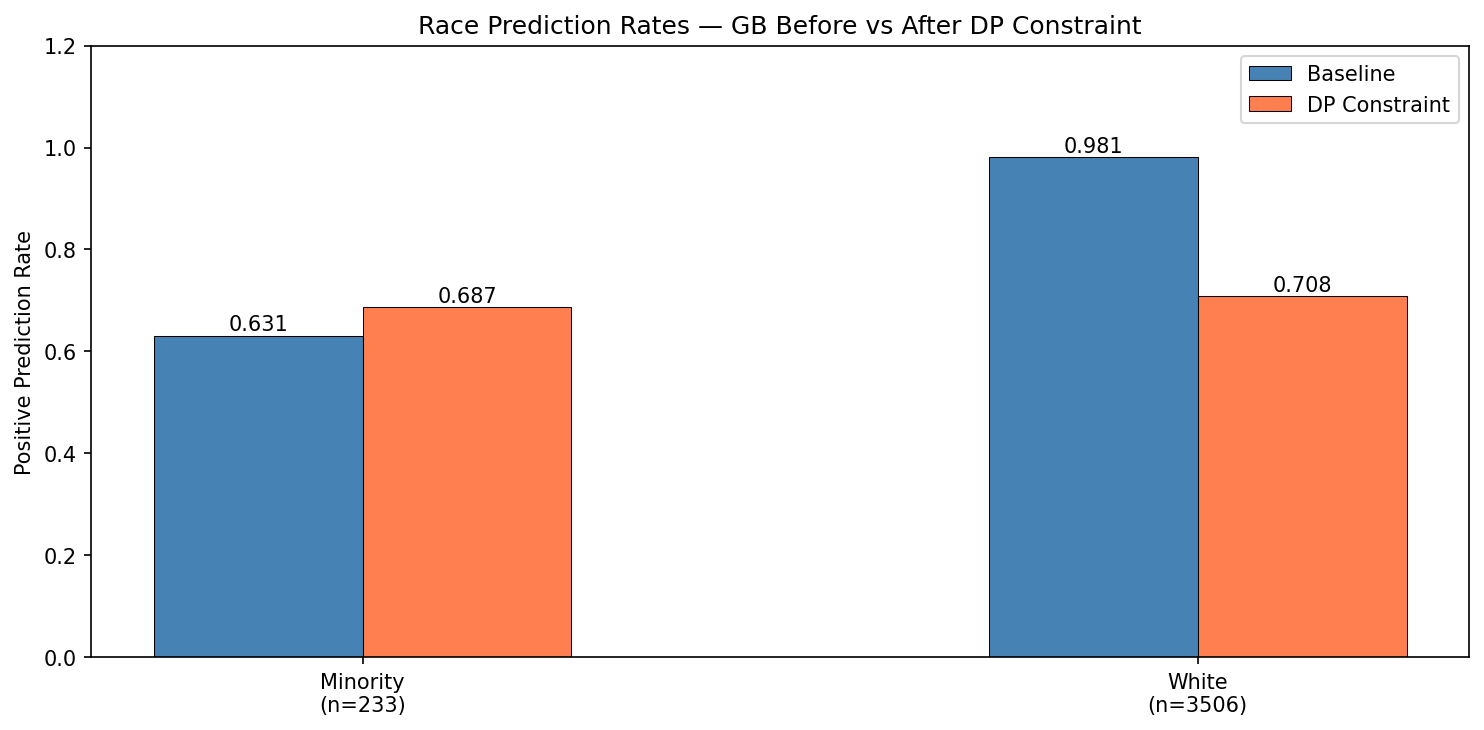

In [8]:
Image('../figures/stage2/lawschool_race_prediction_rates.png')

## 7. FPR/FNR by Race

FPR/FNR gap narrows after DP constraint. GB EO constraint achieves near-equalized error rates.

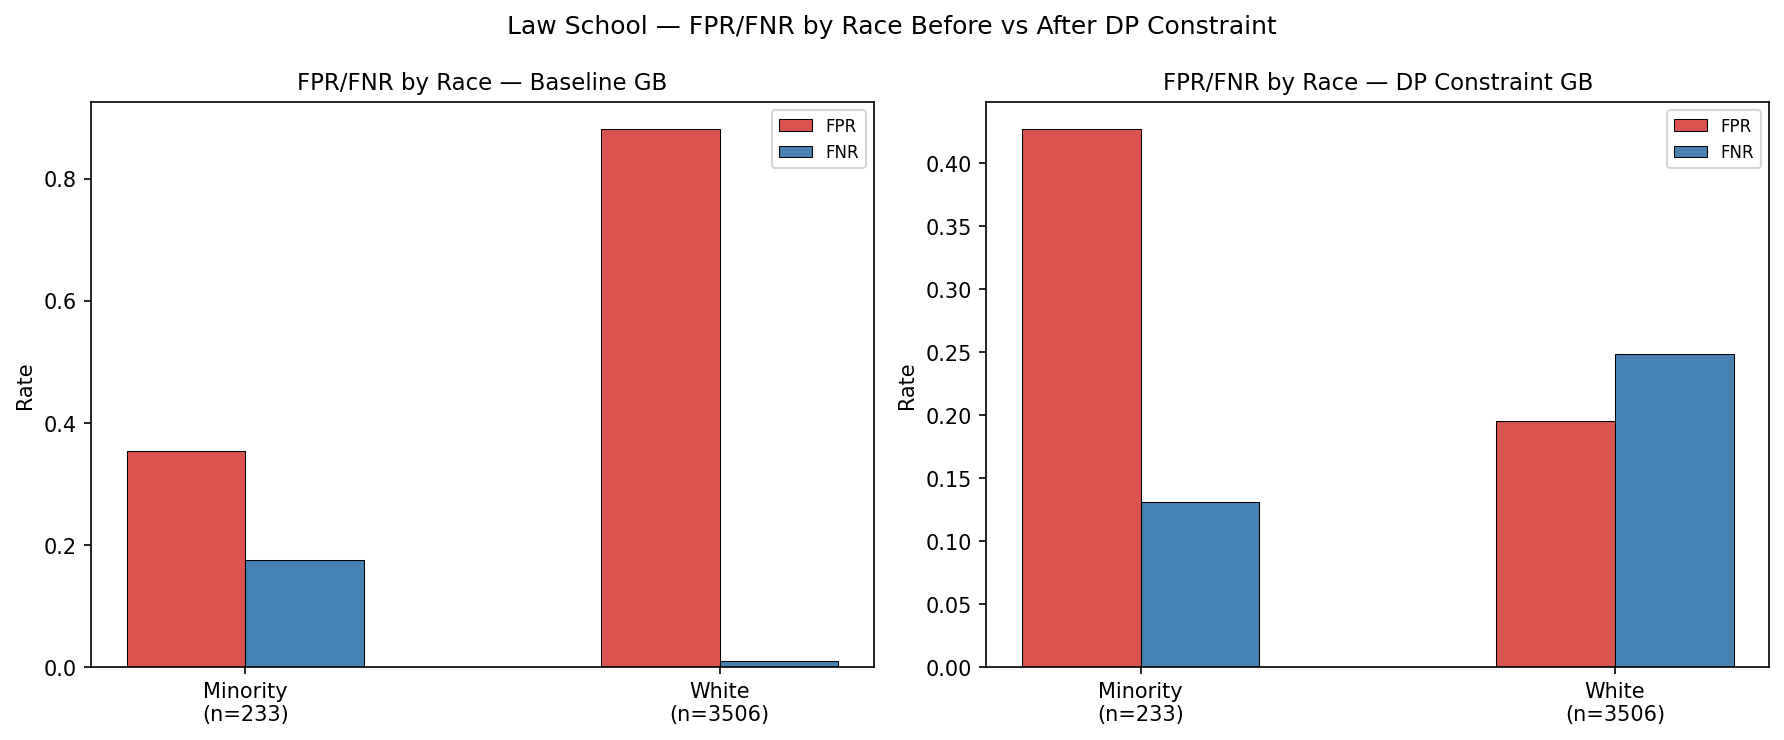

In [9]:
Image('../figures/stage2/lawschool_fpr_fnr_by_race.png')

## 8. Disparate Impact Ratio, Before vs After DP Constraint

Both models cross EEOC 0.8 threshold after intervention. LR: 0.666→0.986. GB: 0.643→0.957.

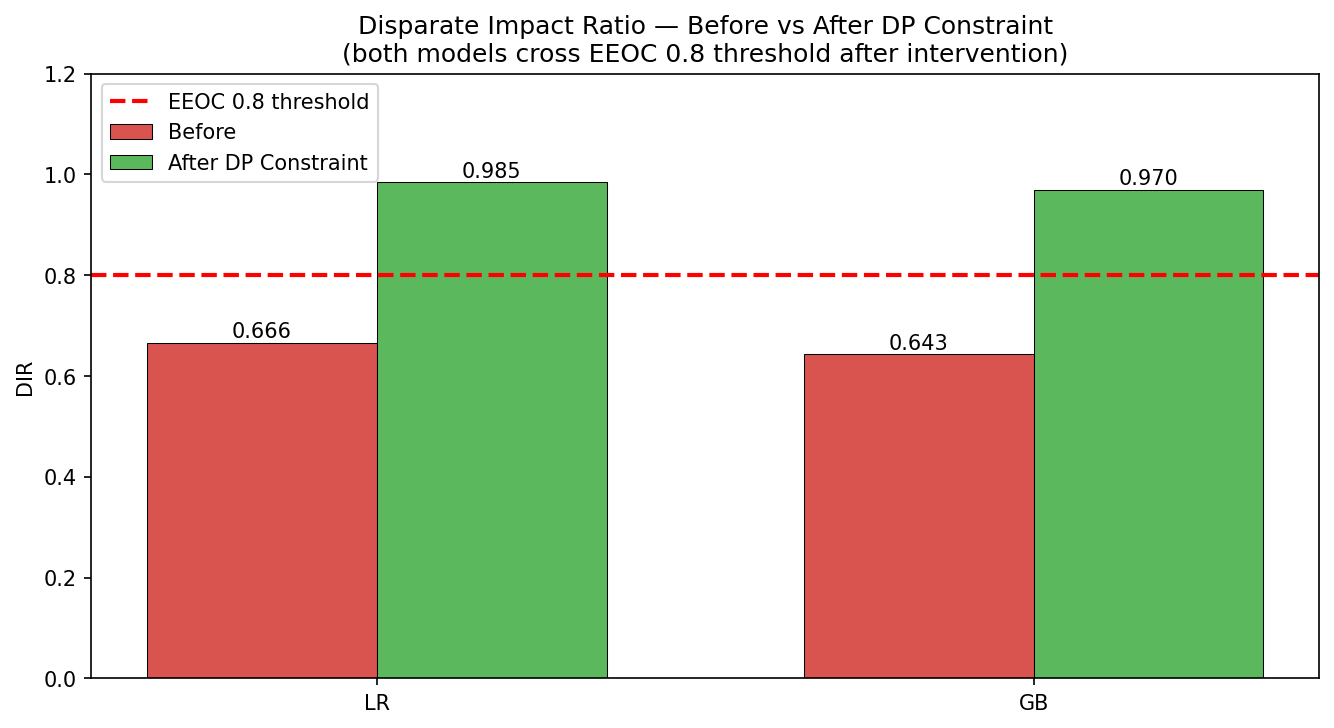

In [10]:
Image('../figures/stage2/lawschool_dir_before_after.png')

## 9. Intersectional Analysis, Race × Sex

Minority Female 64.5%→70.4%, Minority Male 60.5%→63.0%. White groups converge toward parity.

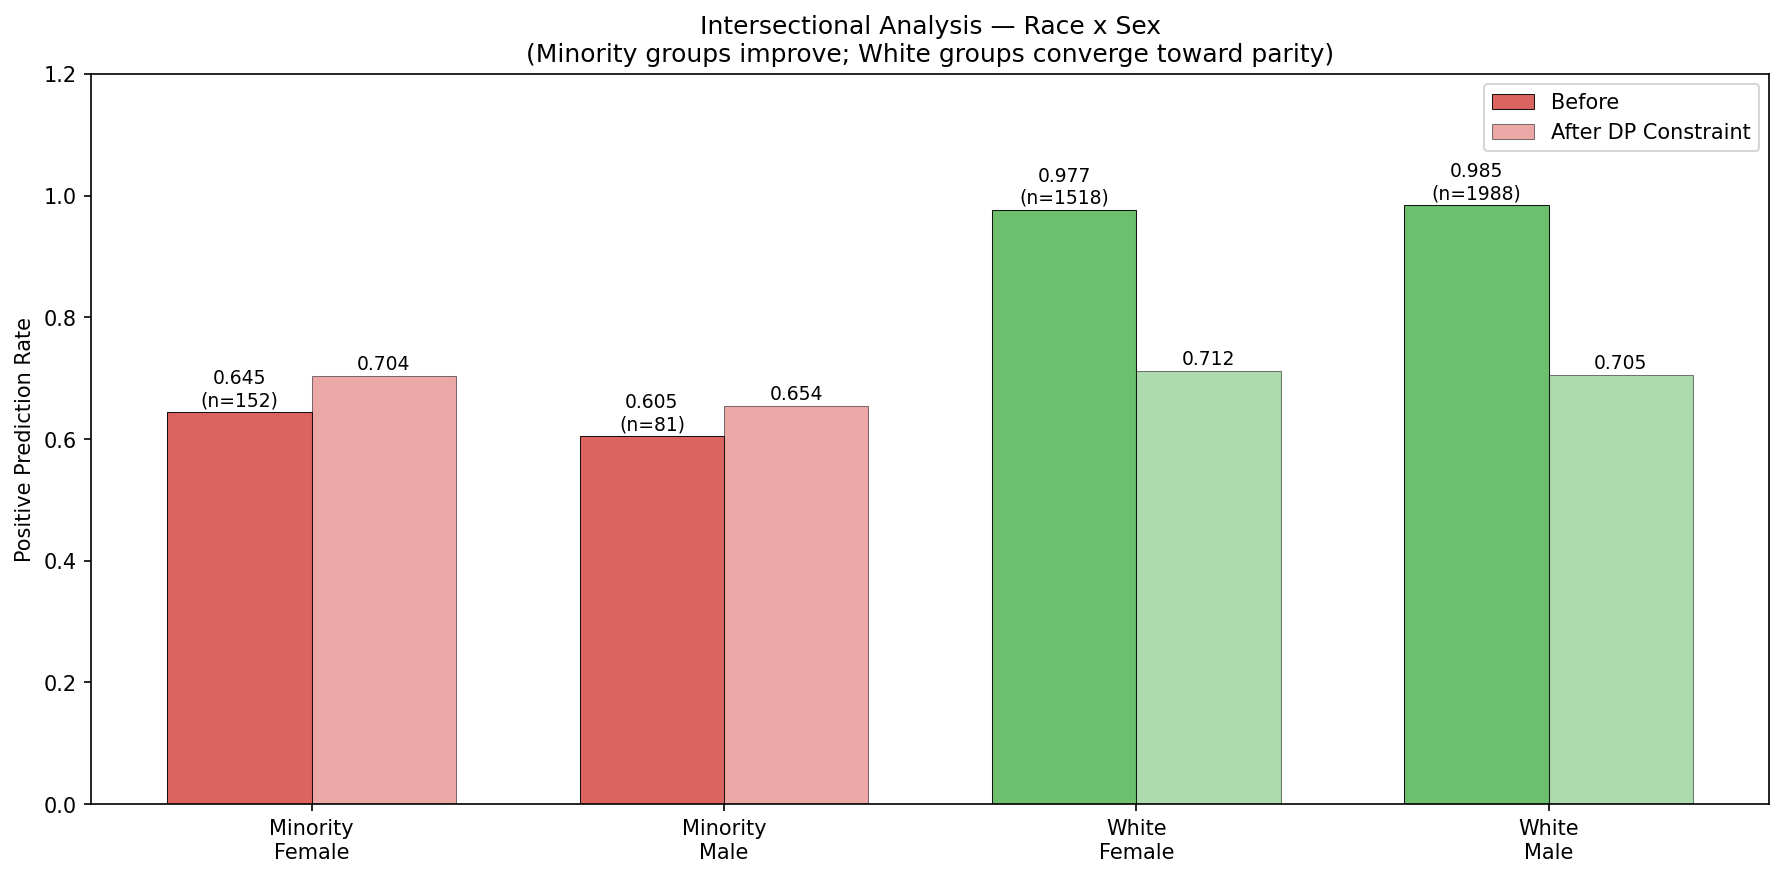

In [11]:
Image('../figures/stage2/lawschool_intersectional_stage2.png')

## 10. Key Findings

**Baseline DIR=0.643**, strongest racial violation in FAPE. Below EEOC 0.8 threshold.

**DP constraint:** Near-complete elimination of DP gap (0.329→0.006). Race prediction rates converge: Minority 63.1%→68.2%, White 98.1%→70.8%.

**EO constraint:** GB achieves EO_diff=0.020, near-equalized odds across race groups.

**Sex gap minimal:** DP<0.015, race dominates fairness concern in Law School domain.

**Accuracy cost:** Acc drops ~0.90→0.75 under DP constraint, acceptable given baseline severity.

**Cross-domain significance:** Largest racial gap in FAPE. Strongest ThresholdOptimizer improvement, validates FAPE cross-domain fairness intervention claim.